# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


## Tentang Dataset

Dataset yang digunakan adalah ***[Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)*** yang diperoleh dari ***Kaggle***.
---

Dataset ini berisi informasi pelanggan perusahaan telekomunikasi seperti data demografi, layanan yang digunakan, biaya bulanan, biaya total, serta status pelanggan apakah berhenti berlangganan (*Churn*) atau tetap menggunakan layanan.

Salah satu tantangan utama perusahaan telekomunikasi adalah *customer churn*, yaitu kondisi ketika pelanggan memutuskan untuk berhenti menggunakan layanan perusahaan. Tingginya tingkat *churn* dapat menyebabkan penurunan pendapatan dan meningkatnya biaya untuk memperoleh pelanggan baru. Oleh karena itu, penting bagi perusahaan untuk mengidentifikasi pelanggan yang berpotensi *churn* sehingga dapat dilakukan strategi retensi pelanggan secara lebih efektif.

Dataset ini digunakan untuk membangun model *machine learning* yang mampu memprediksi apakah seorang pelanggan akan melakukan *churn* atau tidak berdasarkan karakteristik demografi, layanan yang digunakan, serta informasi tagihan pelanggan.
* Jumlah observasi: **7.043 pelanggan**
* Jumlah fitur: **21 variabel**

Berikut adalah informasi terkait variabelnya:

| No. | Nama Variabel | Tipe Data | Deskripsi |
|------|---------------|-----------|-----------|
| 1 | customerID | Object | ID unik untuk setiap pelanggan. |
| 2 | gender | Object | Jenis kelamin pelanggan, yaitu *Male* atau *Female*. |
| 3 | SeniorCitizen | Integer | Status pelanggan sebagai warga senior (1 = Ya, 0 = Tidak). |
| 4 | Partner | Object | Menunjukkan apakah pelanggan memiliki pasangan (*Yes* atau *No*). |
| 5 | Dependents | Object | Menunjukkan apakah pelanggan memiliki tanggungan (*Yes* atau *No*). |
| 6 | tenure | Integer | Lama pelanggan berlangganan layanan dalam satuan bulan. |
| 7 | PhoneService | Object | Menunjukkan apakah pelanggan menggunakan layanan telepon. |
| 8 | MultipleLines | Object | Menunjukkan apakah pelanggan memiliki lebih dari satu jalur telepon. |
| 9 | InternetService | Object | Jenis layanan internet yang digunakan pelanggan, yaitu *DSL*, *Fiber optic*, atau *No*. |
| 10 | OnlineSecurity | Object | Menunjukkan apakah pelanggan menggunakan layanan keamanan online. |
| 11 | OnlineBackup | Object | Menunjukkan apakah pelanggan menggunakan layanan pencadangan (backup) online. |
| 12 | DeviceProtection | Object | Menunjukkan apakah pelanggan menggunakan layanan perlindungan perangkat. |
| 13 | TechSupport | Object | Menunjukkan apakah pelanggan menggunakan layanan dukungan teknis. |
| 14 | StreamingTV | Object | Menunjukkan apakah pelanggan menggunakan layanan streaming TV. |
| 15 | StreamingMovies | Object | Menunjukkan apakah pelanggan menggunakan layanan streaming film. |
| 16 | Contract | Object | Jenis kontrak pelanggan, yaitu *Month-to-month*, *One year*, atau *Two year*. |
| 17 | PaperlessBilling | Object | Menunjukkan apakah pelanggan menggunakan tagihan tanpa kertas (*paperless billing*). |
| 18 | PaymentMethod | Object | Metode pembayaran yang digunakan pelanggan. |
| 19 | MonthlyCharges | Float | Biaya bulanan yang dibayarkan pelanggan. |
| 20 | TotalCharges | Object / Float | Total biaya yang telah dibayarkan pelanggan selama berlangganan. Terdapat beberapa nilai kosong yang tersimpan sebagai string. |
| 21 | Churn | Object | Variabel target yang menunjukkan apakah pelanggan berhenti berlangganan (*Yes*) atau tetap berlangganan (*No*). |


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [238]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [239]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [240]:
df = pd.read_csv(
    '/content/drive/MyDrive/Dicoding/Proyek Membangun Sistem ML/Eksperimen_SML_Brikca-Kristal/telco_raw.csv'
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

## 4.1 Informasi Dataset

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 4.2 Dimensi Dataset

In [242]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 7043
Jumlah Kolom : 21


## 4.3 Statistik Deskriptif

In [243]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4.4 *Missing Value*

In [244]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Dataset tidak memiliki *missing value*.

## 4.5 *Duplicate*

In [245]:
df.duplicated().sum()

np.int64(0)

Tidak terdapat data yang *duplicate*.

## 4.6 Distribusi Target

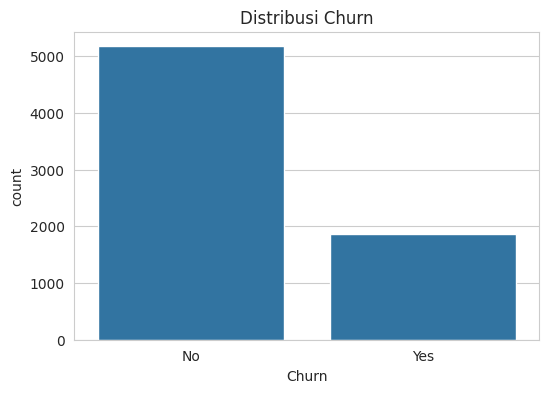

In [246]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Churn'
)

plt.title("Distribusi Churn")
plt.show()

Terlihat bahwa **jumlah pelanggan yang tidak *churn* lebih banyak dibandingkan pelanggan yang *churn***, sehingga terdapat indikasi ketidakseimbangan kelas.

## 4.7 Proporsi Churn

In [247]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


## 4.8 Churn Berdasarkan Gender

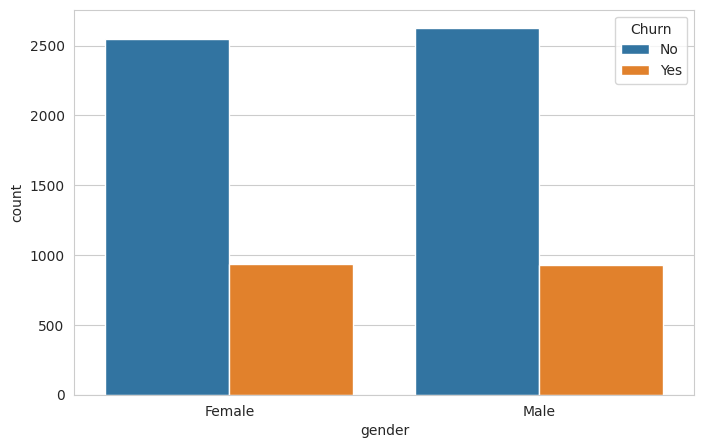

In [248]:
sns.countplot(
    data=df,
    x='gender',
    hue='Churn'
)

plt.show()

## 4.9 Churn Berdasarkan Contract

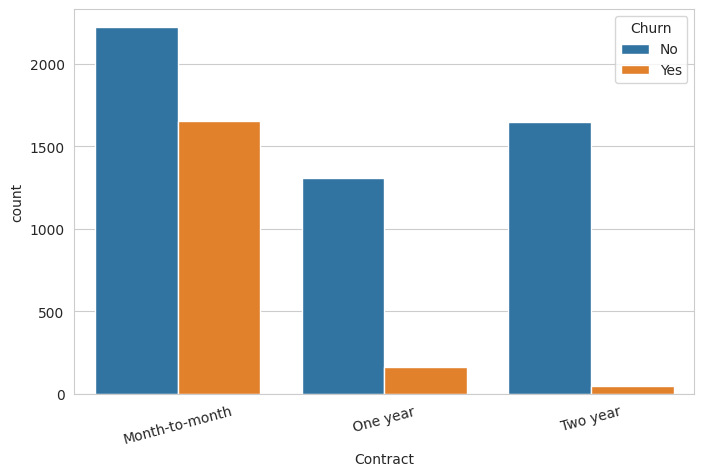

In [249]:
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)

plt.xticks(rotation=15)
plt.show()

Pelanggan dengan kontrak bulanan cenderung memiliki tingkat *churn* yang lebih tinggi dibandingkan pelanggan dengan kontrak satu tahun atau dua tahun.

## 4.10 Churn Berdasarkan Internet Service

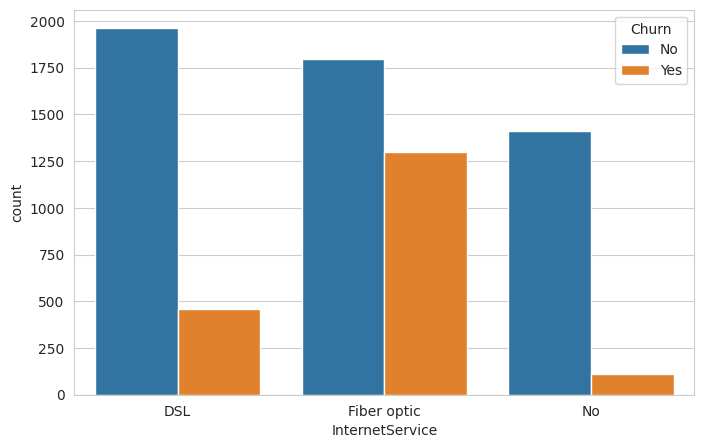

In [250]:
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)

plt.show()

## 4.11 Distribusi Tenure

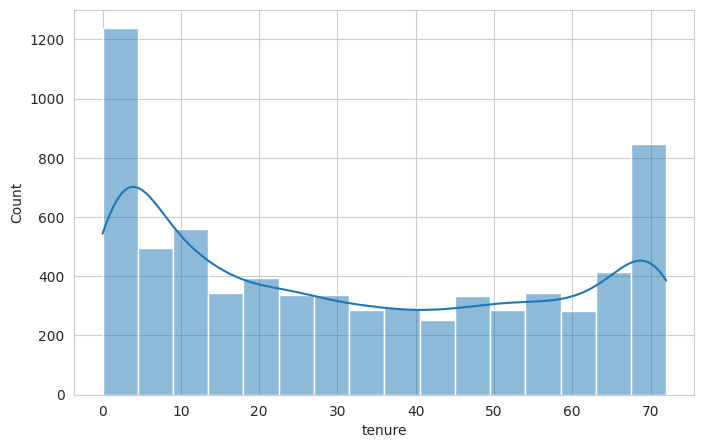

In [251]:
sns.histplot(
    df['tenure'],
    kde=True
)

plt.show()

## 4.12 Distribusi MonthlyCharges

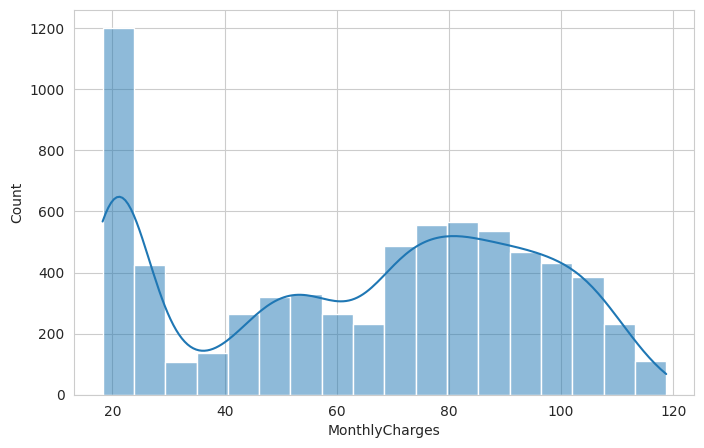

In [252]:
sns.histplot(
    df['MonthlyCharges'],
    kde=True
)

plt.show()

## 4.13 Korelasi Numerik

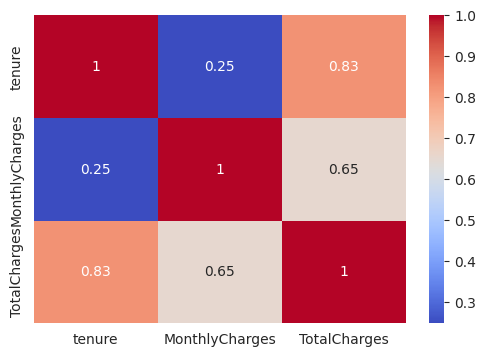

In [253]:
temp = df.copy()

temp['TotalCharges'] = pd.to_numeric(
    temp['TotalCharges'],
    errors='coerce'
)

corr = temp[
    ['tenure','MonthlyCharges','TotalCharges']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

## Identifikasi Unique Value

In [254]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

customerID : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges : ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn : ['No' 'Yes']


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## 5.1 *Copy Dataset*

In [255]:
df_pre = df.copy()

## 5.2 Hapus *customerID*

In [256]:
df_pre.drop(
    'customerID',
    axis=1,
    inplace=True
)

## 5.3 Konversi *TotalCharges*

Pada dataset ini, *TotalCharges* masih bertipe object karena terdapat nilai kosong berupa string.

In [257]:
df_pre['TotalCharges'] = pd.to_numeric(
    df_pre['TotalCharges'],
    errors='coerce'
)

## 5.4 *Missing Value*

In [258]:
df_pre.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Berdasarkan pemeriksaan awal tidak ditemukan *missing value*. Namun, setelah variabel *TotalCharges* dikonversi menjadi numerik, ditemukan 11 nilai kosong yang sebelumnya tersimpan sebagai *string* kosong.

In [259]:
# Drp Missing Value
df_pre.dropna(
    subset=['TotalCharges'],
    inplace=True
)

## 5.5 *Duplicate*

In [260]:
df_pre.duplicated().sum()

np.int64(22)

Setelah variabel *customerID* dihapus, ditemukan 22 observasi yang memiliki karakteristik identik pada seluruh variabel lainnya. Namun, karena *customerID* merupakan identitas unik pelanggan, kondisi ini menunjukkan adanya pelanggan berbeda yang memiliki profil layanan yang sama, bukan kesalahan pencatatan data.

Oleh karena itu, observasi tersebut tetap dipertahankan agar informasi pelanggan tidak hilang.

## 5.6 Cek Oulier

In [261]:
numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

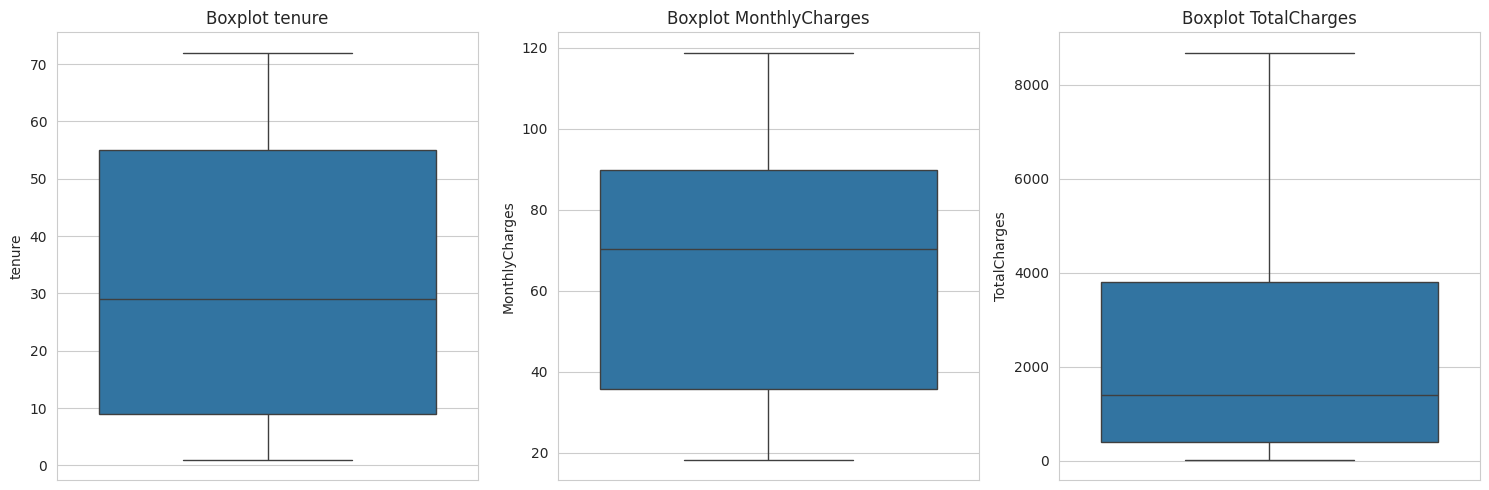

In [262]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols):

    plt.subplot(1,3,i+1)

    sns.boxplot(
        y=df_pre[col]
    )

    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

In [263]:
for col in numerical_cols:

    Q1 = df_pre[col].quantile(0.25)
    Q3 = df_pre[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_pre[
        (df_pre[col] < lower_bound) |
        (df_pre[col] > upper_bound)
    ]

    print(
        f"{col}: {len(outliers)} outlier"
    )

tenure: 0 outlier
MonthlyCharges: 0 outlier
TotalCharges: 0 outlier


Tidak terdapat oulier pada dataset.

## 5.7 Transformasi Nilai

In [264]:
replace_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in replace_cols:

    df_pre[col] = df_pre[col].replace({
        'No internet service':'No',
        'No phone service':'No'
    })

## 5.8 *Encoding* Target

In [265]:
df_pre['Churn'] = df_pre['Churn'].map({
    'Yes':1,
    'No':0
})

In [266]:
df_pre['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


## 5.9 One Hot Encoding Seluruh Variabel Kategorikal

In [267]:
categorical_cols = df_pre.select_dtypes(
    include='object'
).columns

print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [268]:
df_pre = pd.get_dummies(
    df_pre,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [269]:
df_pre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   int64  
 6   Partner_Yes                            7032 non-null   int64  
 7   Dependents_Yes                         7032 non-null   int64  
 8   PhoneService_Yes                       7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetS

*SeniorCitizen* sudah dalam format biner (0/1), sehingga tidak perlu di-encode.

## 5.10 *Scaling*

In [270]:
scaler = StandardScaler()

numerical_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df_pre[numerical_cols] = scaler.fit_transform(
    df_pre[numerical_cols]
)

In [271]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [272]:
df_pre.shape

(7032, 24)

In [273]:
df_pre.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,0.064303,-0.260878,-0.173740,0,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,-1.239504,-0.363923,-0.959649,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,0.512486,-0.747850,-0.195248,0,1,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,-1.239504,0.196178,-0.940457,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## Kesimpulan Preprocessing

Berdasarkan tahapan preprocessing yang telah dilakukan, dataset berhasil dibersihkan dan dipersiapkan untuk proses pembangunan model machine learning.

Tahapan yang dilakukan meliputi:

- Penghapusan variabel *customerID*
- Konversi tipe data *TotalCharges*
- Penanganan *missing value*
- Analisis *duplicate* data
- Deteksi outlier
- Transformasi kategori layanan
- *Encoding* variabel kategorikal
- Standardisasi variabel numerik

Dataset hasil preprocessing memiliki 7032 observasi dan 24 variabel serta telah siap digunakan pada tahap pelatihan model.

# **6. Simpan Dataset**

In [274]:
df_pre.to_csv(
    "telco_preprocessed.csv",
    index=False
)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.
